# MovieLens Knowledge Graph

MovieLens 1M の変換済みデータを読み込み、属性グラフ構築に使う入力テーブルを準備する。

## Data Load

このノートでは、属性グラフの構築でそのまま扱いやすい `transformed parquet` を中心にロードする。

In [154]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

In [155]:
DATA_DIR = Path("./data")

movies_df = pd.read_parquet(DATA_DIR / "movies_transformed.parquet")
users_df = pd.read_parquet(DATA_DIR / "users_transformed.parquet")
ratings_df = pd.read_parquet(DATA_DIR / "ratings_transformed.parquet")
transaction_df = pd.read_parquet(DATA_DIR / "transaction.parquet")

In [156]:
pd.DataFrame(
    {
        "table_name": [
            "movies_transformed",
            "users_transformed",
            "ratings_transformed",
            "transaction",
        ],
        "rows": [
            len(movies_df),
            len(users_df),
            len(ratings_df),
            len(transaction_df),
        ],
        "columns": [
            movies_df.shape[1],
            users_df.shape[1],
            ratings_df.shape[1],
            transaction_df.shape[1],
        ],
    }
)

,table_name,rows,columns
0,movies_transformed,3883,33
1,users_transformed,6040,37
2,ratings_transformed,1000209,7
3,transaction,1000209,70


## Attribute Node Definition

属性グラフでは、one-hot 化された属性列名をそのまま node id として扱う。

In [157]:
user_attribute_columns = [
    column
    for column in users_df.columns
    if column.startswith(("gender_", "age_", "occupation_"))
    and column not in {"age_category", "occupation_category"}
]

movie_genre_columns = [
    column for column in movies_df.columns if column.startswith("genre_")
]

movie_decade_columns = [
    column
    for column in movies_df.columns
    if column.startswith("release_decade_") and column != "release_decade"
]

movie_attribute_columns = movie_genre_columns + movie_decade_columns

In [158]:
attribute_column_config = {
    "user_attributes": user_attribute_columns,
    "movie_genres": movie_genre_columns,
    "movie_decades": movie_decade_columns,
    "movie_attributes": movie_attribute_columns,
}

pd.DataFrame(
    [
        {"attribute_group": group, "column_name": column}
        for group, columns in attribute_column_config.items()
        for column in columns
    ]
)

,attribute_group,column_name
0,user_attributes,gender_F
1,user_attributes,gender_M
2,user_attributes,age_18_24
3,user_attributes,age_25_34
4,user_attributes,age_35_44
...,...,...
81,movie_attributes,release_decade_1960s
82,movie_attributes,release_decade_1970s
83,movie_attributes,release_decade_1980s
84,movie_attributes,release_decade_1990s


In [159]:
attribute_node_summary = pd.DataFrame(
    {
        "attribute_group": [
            "user_attributes",
            "movie_genres",
            "movie_decades",
            "movie_attributes",
        ],
        "node_count": [
            len(user_attribute_columns),
            len(movie_genre_columns),
            len(movie_decade_columns),
            len(movie_attribute_columns),
        ],
    }
)

attribute_node_summary

,attribute_group,node_count
0,user_attributes,30
1,movie_genres,18
2,movie_decades,10
3,movie_attributes,28


## User Attribute To Movie Attribute Edges

`rating >= 4` を支持イベントとみなし、user attribute と movie attribute の直積からエッジを構築する。

In [160]:
POSITIVE_INTERACTION_COLUMN = "rating_ge_4"
MIN_LIFT_EVENT_COUNT = 30
USER_ATTRIBUTE_SHARE_THRESHOLD = 0.20

In [161]:
def collect_active_attribute_events(
    df: pd.DataFrame,
    event_id_column: str,
    attribute_columns: list[str],
    output_column_name: str,
) -> pd.DataFrame:
    event_frames = [
        df.loc[df[column] == 1, [event_id_column]].assign(**{output_column_name: column})
        for column in attribute_columns
    ]
    return pd.concat(event_frames, ignore_index=True)


def build_user_to_movie_edges(
    transaction_df: pd.DataFrame,
    user_attribute_columns: list[str],
    movie_attribute_columns: list[str],
    positive_interaction_column: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    positive_transactions = (
        transaction_df.loc[
            transaction_df[positive_interaction_column] == 1,
            ["user_id", "movie_id", positive_interaction_column]
            + user_attribute_columns
            + movie_attribute_columns,
        ]
        .reset_index(drop=True)
        .reset_index(names="event_id")
    )

    user_events = collect_active_attribute_events(
        positive_transactions,
        event_id_column="event_id",
        attribute_columns=user_attribute_columns,
        output_column_name="source",
    )
    movie_events = collect_active_attribute_events(
        positive_transactions,
        event_id_column="event_id",
        attribute_columns=movie_attribute_columns,
        output_column_name="target",
    )

    edge_events = user_events.merge(movie_events, on="event_id", how="inner")

    edge_counts = (
        edge_events.groupby(["source", "target"], as_index=False)
        .size()
        .rename(columns={"size": "positive_event_count"})
    )
    source_totals = edge_counts.groupby("source", as_index=False)["positive_event_count"].sum()
    source_totals = source_totals.rename(
        columns={"positive_event_count": "source_total_positive_events"}
    )
    target_totals = edge_counts.groupby("target", as_index=False)["positive_event_count"].sum()
    target_totals = target_totals.rename(
        columns={"positive_event_count": "target_total_positive_events"}
    )

    global_positive_events = len(edge_events)

    edges = (
        edge_counts.merge(source_totals, on="source", how="left")
        .merge(target_totals, on="target", how="left")
        .assign(
            edge_type="user_to_movie",
            global_positive_events=global_positive_events,
        )
    )
    edges["conditional_prob"] = (
        edges["positive_event_count"] / edges["source_total_positive_events"]
    )
    edges["target_positive_rate"] = (
        edges["target_total_positive_events"] / edges["global_positive_events"]
    )
    edges["lift"] = edges["conditional_prob"] / edges["target_positive_rate"]

    return positive_transactions, edges.sort_values(
        ["positive_event_count", "lift"], ascending=[False, False]
    ).reset_index(drop=True)


def build_structural_movie_edges(
    movies_df: pd.DataFrame,
    movie_attribute_columns: list[str],
) -> pd.DataFrame:
    movie_attribute_events = collect_active_attribute_events(
        movies_df.reset_index(drop=True).reset_index(names="entity_id"),
        event_id_column="entity_id",
        attribute_columns=movie_attribute_columns,
        output_column_name="attribute",
    )
    edge_events = movie_attribute_events.merge(
        movie_attribute_events,
        on="entity_id",
        how="inner",
        suffixes=("_a", "_b"),
    )
    edge_events = edge_events.loc[
        edge_events["attribute_a"] < edge_events["attribute_b"]
    ]

    edge_counts = (
        edge_events.groupby(["attribute_a", "attribute_b"], as_index=False)
        .size()
        .rename(columns={
            "attribute_a": "source",
            "attribute_b": "target",
            "size": "cooccurrence_count",
        })
    )
    attribute_counts = movie_attribute_events.groupby("attribute", as_index=False).size()
    source_totals = attribute_counts.rename(
        columns={"attribute": "source", "size": "source_attribute_count"}
    )
    target_totals = attribute_counts.rename(
        columns={"attribute": "target", "size": "target_attribute_count"}
    )

    total_movies = len(movies_df)

    edges = (
        edge_counts.merge(source_totals, on="source", how="left")
        .merge(target_totals, on="target", how="left")
        .assign(edge_type="movie_to_movie_structural", total_entities=total_movies)
    )
    edges["source_support_rate"] = edges["cooccurrence_count"] / edges["source_attribute_count"]
    edges["target_support_rate"] = edges["cooccurrence_count"] / edges["target_attribute_count"]
    edges["jaccard"] = edges["cooccurrence_count"] / (
        edges["source_attribute_count"]
        + edges["target_attribute_count"]
        - edges["cooccurrence_count"]
    )
    edges["lift"] = (
        (edges["cooccurrence_count"] / edges["total_entities"])
        / (
            (edges["source_attribute_count"] / edges["total_entities"])
            * (edges["target_attribute_count"] / edges["total_entities"])
        )
    )
    return edges.sort_values(["cooccurrence_count", "lift"], ascending=[False, False]).reset_index(drop=True)


def build_user_preference_movie_edges(
    positive_transactions_df: pd.DataFrame,
    attribute_columns: list[str],
    edge_type: str,
    user_attribute_share_threshold: float,
) -> pd.DataFrame:
    user_positive_movie_counts = (
        positive_transactions_df.groupby("user_id", as_index=False)
        .size()
        .rename(columns={"size": "positive_movie_count"})
    )
    user_attribute_counts = (
        positive_transactions_df[["user_id"] + attribute_columns]
        .groupby("user_id", as_index=False)[attribute_columns]
        .sum()
    )
    user_attribute_matrix = user_attribute_counts.merge(
        user_positive_movie_counts,
        on="user_id",
        how="left",
    )
    for column in attribute_columns:
        user_attribute_matrix[column] = (
            user_attribute_matrix[column] / user_attribute_matrix["positive_movie_count"]
            >= user_attribute_share_threshold
        ).astype(int)
    user_attribute_matrix = user_attribute_matrix[["user_id"] + attribute_columns]
    user_attribute_events = collect_active_attribute_events(
        user_attribute_matrix,
        event_id_column="user_id",
        attribute_columns=attribute_columns,
        output_column_name="attribute",
    )
    edge_events = user_attribute_events.merge(
        user_attribute_events,
        on="user_id",
        how="inner",
        suffixes=("_a", "_b"),
    )
    edge_events = edge_events.loc[
        edge_events["attribute_a"] < edge_events["attribute_b"]
    ]

    edge_counts = (
        edge_events.groupby(["attribute_a", "attribute_b"], as_index=False)
        .size()
        .rename(columns={
            "attribute_a": "source",
            "attribute_b": "target",
            "size": "cooccurrence_count",
        })
    )
    attribute_counts = user_attribute_events.groupby("attribute", as_index=False).size()
    source_totals = attribute_counts.rename(
        columns={"attribute": "source", "size": "source_user_count"}
    )
    target_totals = attribute_counts.rename(
        columns={"attribute": "target", "size": "target_user_count"}
    )

    total_users = positive_transactions_df["user_id"].nunique()

    edges = (
        edge_counts.merge(source_totals, on="source", how="left")
        .merge(target_totals, on="target", how="left")
        .assign(edge_type=edge_type, total_entities=total_users)
    )
    edges["source_support_rate"] = edges["cooccurrence_count"] / edges["source_user_count"]
    edges["target_support_rate"] = edges["cooccurrence_count"] / edges["target_user_count"]
    edges["jaccard"] = edges["cooccurrence_count"] / (
        edges["source_user_count"]
        + edges["target_user_count"]
        - edges["cooccurrence_count"]
    )
    edges["lift"] = (
        (edges["cooccurrence_count"] / edges["total_entities"])
        / (
            (edges["source_user_count"] / edges["total_entities"])
            * (edges["target_user_count"] / edges["total_entities"])
        )
    )
    return edges.sort_values(["cooccurrence_count", "lift"], ascending=[False, False]).reset_index(drop=True)


def build_graph_edge_tables(
    user_to_movie_edges: pd.DataFrame,
    movie_structural_edges: pd.DataFrame,
    movie_preference_genre_edges: pd.DataFrame,
    movie_preference_decade_edges: pd.DataFrame,
    min_user_to_movie_count: int,
) -> dict[str, pd.DataFrame]:
    user_movie_graph_edges = (
        user_to_movie_edges.loc[
            user_to_movie_edges["positive_event_count"] >= min_user_to_movie_count,
            ["source", "target", "edge_type", "positive_event_count", "lift"],
        ]
        .rename(columns={"positive_event_count": "raw_count", "lift": "weight"})
        .assign(weight_metric="lift", is_directed=True)
        .reset_index(drop=True)
    )

    movie_structural_graph_edges = (
        movie_structural_edges.loc[
            :,
            ["source", "target", "edge_type", "cooccurrence_count", "lift"],
        ]
        .rename(columns={"cooccurrence_count": "raw_count", "lift": "weight"})
        .assign(weight_metric="lift", is_directed=False)
        .reset_index(drop=True)
    )

    movie_preference_graph_edges = (
        movie_preference_genre_edges.loc[
            :,
            ["source", "target", "edge_type", "cooccurrence_count", "lift"],
        ]
        .rename(columns={"cooccurrence_count": "raw_count", "lift": "weight"})
        .assign(weight_metric="lift", is_directed=False)
        .reset_index(drop=True)
    )

    all_graph_edges = pd.concat(
        [
            user_movie_graph_edges,
            movie_structural_graph_edges,
            movie_preference_graph_edges,
        ],
        ignore_index=True,
    )

    return {
        "user_movie_graph_edges": user_movie_graph_edges,
        "movie_structural_graph_edges": movie_structural_graph_edges,
        "movie_preference_graph_edges": movie_preference_graph_edges,
        "all_graph_edges": all_graph_edges,
    }


In [162]:
positive_transactions_df, user_to_movie_edges = build_user_to_movie_edges(
    transaction_df=transaction_df,
    user_attribute_columns=user_attribute_columns,
    movie_attribute_columns=movie_attribute_columns,
    positive_interaction_column=POSITIVE_INTERACTION_COLUMN,
)

movie_structural_edges = build_structural_movie_edges(
    movies_df=movies_df,
    movie_attribute_columns=movie_attribute_columns,
)

movie_preference_genre_edges = build_user_preference_movie_edges(
    positive_transactions_df=positive_transactions_df,
    attribute_columns=movie_genre_columns,
    edge_type="movie_to_movie_preference_genre",
    user_attribute_share_threshold=USER_ATTRIBUTE_SHARE_THRESHOLD,
)

movie_preference_decade_edges = build_user_preference_movie_edges(
    positive_transactions_df=positive_transactions_df,
    attribute_columns=movie_decade_columns,
    edge_type="movie_to_movie_preference_decade",
    user_attribute_share_threshold=USER_ATTRIBUTE_SHARE_THRESHOLD,
)

nodes_df = pd.concat(
    [
        pd.DataFrame(
            {
                "node_id": user_attribute_columns,
                "node_type": "user_attribute",
                "node_group": "user",
            }
        ),
        pd.DataFrame(
            {
                "node_id": movie_genre_columns,
                "node_type": "movie_genre",
                "node_group": "movie",
            }
        ),
        pd.DataFrame(
            {
                "node_id": movie_decade_columns,
                "node_type": "movie_decade",
                "node_group": "movie",
            }
        ),
    ],
    ignore_index=True,
).sort_values(["node_group", "node_type", "node_id"]).reset_index(drop=True)

graph_edge_tables = build_graph_edge_tables(
    user_to_movie_edges=user_to_movie_edges,
    movie_structural_edges=movie_structural_edges,
    movie_preference_genre_edges=movie_preference_genre_edges,
    movie_preference_decade_edges=movie_preference_decade_edges,
    min_user_to_movie_count=MIN_LIFT_EVENT_COUNT,
)

user_movie_graph_edges = graph_edge_tables["user_movie_graph_edges"]
movie_structural_graph_edges = graph_edge_tables["movie_structural_graph_edges"]
movie_preference_graph_edges = graph_edge_tables["movie_preference_graph_edges"]
all_graph_edges = graph_edge_tables["all_graph_edges"]

### `user_to_movie_edges` Column Definition

| column | meaning |
| --- | --- |
| `source` | user attribute node id。例: `gender_M`, `age_25_34`, `occupation_programmer` |
| `target` | movie attribute node id。例: `genre_Sci-Fi`, `release_decade_1990s` |
| `positive_event_count` | `rating >= 4` の支持イベントから集計した、`source -> target` の生起回数 |
| `source_total_positive_events` | ある `source` から出る全 `positive_event_count` の合計 |
| `target_total_positive_events` | ある `target` に入る全 `positive_event_count` の合計 |
| `edge_type` | エッジ種別。この notebook では `user_to_movie` を格納する |
| `global_positive_events` | 全 `source -> target` edge event の総数 |
| `conditional_prob` | ある `source` から出る支持イベントのうち、`target` につながる割合 |
| `target_positive_rate` | 全体で見た `target` の出現率。`target_total_positive_events / global_positive_events` |
| `lift` | `conditional_prob / target_positive_rate`。全体平均に対してどれだけ強い接続かを表す |


## Movie Attribute To Movie Attribute Edges

movie attribute 同士の共起は、同一映画内の構造共起と、ユーザー支持を介した共起を分けて構築する。

### Movie Co-Occurrence Tables

| table | meaning |
| --- | --- |
| `movie_structural_edges` | 同一映画内で共起する movie attribute の組。`genre` と `release_decade` の cross-type edge も含む |
| `movie_preference_genre_edges` | 同じユーザーの positive movie のうち 20% 以上を占める genre を支持集合とした `genre <-> genre` 共起 |
| `movie_preference_decade_edges` | 同じユーザーの positive movie のうち 20% 以上を占める decade を支持集合とした `release_decade <-> release_decade` 共起 |


### `lift` And `jaccard`

- `jaccard`
  2つの属性を持つ entity の重なり具合を表す。両方を持つ entity 数を、どちらか一方でも持つ entity 数で割った値。
  値が大きいほど、2つの属性は似た範囲で一緒に現れやすい。

- `lift`
  2つの属性が独立に出ると仮定したときの期待値に対して、実際の共起がどれだけ強いかを表す。
  `1` 付近なら期待通り、`1` より大きければ期待以上に強い共起、`1` より小さければ期待より弱い共起と読む。

## Graph Tables

`networkx` に流す前段として、node table と共通 edge schema を作る。

### Graph Schema

| table | role |
| --- | --- |
| `nodes_df` | 全 node の一覧。`node_id`、`node_type`、`node_group` を持つ |
| `user_movie_graph_edges` | `user_to_movie` 用の graph edge table。`weight` は `lift` を使う |
| `movie_structural_graph_edges` | 構造共起用の graph edge table。`weight` は `lift` を使う |
| `movie_preference_graph_edges` | ユーザー支持共起用の graph edge table。genre ベースのみを含み、`weight` は `lift` を使う |
| `all_graph_edges` | 上記3種を連結した統合 edge table |


In [163]:
pd.DataFrame(
    {
        "table_name": [
            "nodes_df",
            "user_to_movie_edges",
            "movie_structural_edges",
            "movie_preference_genre_edges",
            "movie_preference_decade_edges",
            "user_movie_graph_edges",
            "movie_structural_graph_edges",
            "movie_preference_graph_edges",
            "all_graph_edges",
        ],
        "rows": [
            len(nodes_df),
            len(user_to_movie_edges),
            len(movie_structural_edges),
            len(movie_preference_genre_edges),
            len(movie_preference_decade_edges),
            len(user_movie_graph_edges),
            len(movie_structural_graph_edges),
            len(movie_preference_graph_edges),
            len(all_graph_edges),
        ],
    }
)

,table_name,rows
0,nodes_df,58
1,user_to_movie_edges,829
2,movie_structural_edges,272
3,movie_preference_genre_edges,146
4,movie_preference_decade_edges,26
5,user_movie_graph_edges,796
6,movie_structural_graph_edges,272
7,movie_preference_graph_edges,146
8,all_graph_edges,1214


In [164]:
nodes_df.head(20)

,node_id,node_type,node_group
0,release_decade_1910s,movie_decade,movie
1,release_decade_1920s,movie_decade,movie
2,release_decade_1930s,movie_decade,movie
3,release_decade_1940s,movie_decade,movie
4,release_decade_1950s,movie_decade,movie
5,release_decade_1960s,movie_decade,movie
6,release_decade_1970s,movie_decade,movie
7,release_decade_1980s,movie_decade,movie
8,release_decade_1990s,movie_decade,movie
9,release_decade_2000s,movie_decade,movie


In [165]:
user_to_movie_edges.head(20)

,source,target,positive_event_count,source_total_positive_events,target_total_positive_events,edge_type,global_positive_events,conditional_prob,target_positive_rate,lift
0,gender_M,release_decade_1990s,207748,1338253,850776,user_to_movie,5346840,0.155238,0.159118,0.975620
1,gender_M,genre_Drama,165059,1338253,685320,user_to_movie,5346840,0.123339,0.128173,0.962287
2,gender_M,genre_Comedy,142014,1338253,590835,user_to_movie,5346840,0.106119,0.110502,0.960338
3,age_25_34,release_decade_1990s,114876,689784,850776,user_to_movie,5346840,0.166539,0.159118,1.046642
4,gender_M,genre_Action,114061,1338253,416298,user_to_movie,5346840,0.085231,0.077859,1.094692
5,gender_M,release_decade_1980s,99335,1338253,388530,user_to_movie,5346840,0.074227,0.072665,1.021496
6,age_25_34,genre_Drama,87431,689784,685320,user_to_movie,5346840,0.126751,0.128173,0.988909
7,gender_M,genre_Thriller,85045,1338253,324648,user_to_movie,5346840,0.063549,0.060718,1.046634
8,age_25_34,genre_Comedy,77659,689784,590835,user_to_movie,5346840,0.112585,0.110502,1.018849
9,gender_F,release_decade_1990s,75844,444027,850776,user_to_movie,5346840,0.170809,0.159118,1.073480


In [166]:
user_to_movie_edges.loc[
    user_to_movie_edges["positive_event_count"] >= MIN_LIFT_EVENT_COUNT
].sort_values("lift", ascending=False).head(20)

,source,target,positive_event_count,source_total_positive_events,target_total_positive_events,edge_type,global_positive_events,conditional_prob,target_positive_rate,lift
640,occupation_retired,release_decade_1940s,549,26740,48360,user_to_movie,5346840,0.020531,0.009045,2.269979
360,age_56_plus,release_decade_1950s,2416,75586,76155,user_to_movie,5346840,0.031964,0.014243,2.244163
583,occupation_retired,release_decade_1950s,818,26740,76155,user_to_movie,5346840,0.030591,0.014243,2.147784
537,occupation_k12_student,release_decade_2000s,1022,42098,63033,user_to_movie,5346840,0.024277,0.011789,2.059295
587,occupation_tradesman_craftsman,genre_Horror,798,20298,102264,user_to_movie,5346840,0.039314,0.019126,2.055531
415,occupation_k12_student,genre_Children's,1808,42098,111834,user_to_movie,5346840,0.042947,0.020916,2.053337
481,age_56_plus,release_decade_1940s,1377,75586,48360,user_to_movie,5346840,0.018218,0.009045,2.014204
397,age_under_18,genre_Children's,2037,49012,111834,user_to_movie,5346840,0.041561,0.020916,1.987064
709,occupation_retired,release_decade_1930s,280,26740,28329,user_to_movie,5346840,0.010471,0.005298,1.976344
505,occupation_k12_student,genre_Animation,1203,42098,79908,user_to_movie,5346840,0.028576,0.014945,1.912102


In [167]:
movie_structural_edges.head(20)

,source,target,cooccurrence_count,source_attribute_count,target_attribute_count,edge_type,total_entities,source_support_rate,target_support_rate,jaccard,lift
0,genre_Drama,release_decade_1990s,1036,1603,2283,movie_to_movie_structural,3883,0.646288,0.453789,0.363509,1.099228
1,genre_Comedy,release_decade_1990s,743,1200,2283,movie_to_movie_structural,3883,0.619167,0.325449,0.271168,1.053099
2,genre_Romance,release_decade_1990s,333,471,2283,movie_to_movie_structural,3883,0.707006,0.145861,0.137546,1.202499
3,genre_Thriller,release_decade_1990s,322,492,2283,movie_to_movie_structural,3883,0.654472,0.141042,0.131268,1.113146
4,genre_Action,release_decade_1990s,299,503,2283,movie_to_movie_structural,3883,0.594433,0.130968,0.120225,1.011031
5,genre_Comedy,genre_Drama,226,1200,1603,movie_to_movie_structural,3883,0.188333,0.140986,0.087699,0.456206
6,genre_Drama,release_decade_1980s,211,1603,598,movie_to_movie_structural,3883,0.131628,0.352843,0.106030,0.854703
7,genre_Comedy,genre_Romance,204,1200,471,movie_to_movie_structural,3883,0.170000,0.433121,0.139059,1.401507
8,genre_Drama,genre_Romance,204,1603,471,movie_to_movie_structural,3883,0.127261,0.433121,0.109091,1.049163
9,genre_Comedy,release_decade_1980s,200,1200,598,movie_to_movie_structural,3883,0.166667,0.334448,0.125156,1.082219


In [168]:
movie_preference_genre_edges.head(20)

,source,target,cooccurrence_count,source_user_count,target_user_count,edge_type,total_entities,source_support_rate,target_support_rate,jaccard,lift
0,genre_Comedy,genre_Drama,4201,4718,5318,movie_to_movie_preference_genre,6038,0.890420,0.789959,0.719966,1.010973
1,genre_Action,genre_Drama,2669,3156,5318,movie_to_movie_preference_genre,6038,0.845691,0.501880,0.459776,0.960188
2,genre_Action,genre_Comedy,2256,3156,4718,movie_to_movie_preference_genre,6038,0.714829,0.478169,0.401566,0.914823
3,genre_Drama,genre_Thriller,2208,5318,2564,movie_to_movie_preference_genre,6038,0.415194,0.861154,0.389143,0.977745
4,genre_Action,genre_Thriller,1895,3156,2564,movie_to_movie_preference_genre,6038,0.600444,0.739080,0.495425,1.413993
5,genre_Comedy,genre_Thriller,1654,4718,2564,movie_to_movie_preference_genre,6038,0.350572,0.645086,0.293888,0.825568
6,genre_Action,genre_Sci-Fi,1414,3156,1536,movie_to_movie_preference_genre,6038,0.448035,0.920573,0.431361,1.761223
7,genre_Drama,genre_Sci-Fi,1136,5318,1536,movie_to_movie_preference_genre,6038,0.213614,0.739583,0.198671,0.839715
8,genre_Action,genre_Adventure,1119,3156,1188,movie_to_movie_preference_genre,6038,0.354563,0.941919,0.346977,1.802062
9,genre_Drama,genre_Romance,1090,5318,1192,movie_to_movie_preference_genre,6038,0.204964,0.914430,0.201107,1.038233


In [169]:
movie_preference_decade_edges.head(20)

,source,target,cooccurrence_count,source_user_count,target_user_count,edge_type,total_entities,source_support_rate,target_support_rate,jaccard,lift
0,release_decade_1980s,release_decade_1990s,2771,3030,5554,movie_to_movie_preference_decade,6038,0.914521,0.498920,0.476690,0.994217
1,release_decade_1970s,release_decade_1990s,331,500,5554,movie_to_movie_preference_decade,6038,0.662000,0.059597,0.057837,0.719690
2,release_decade_1970s,release_decade_1980s,302,500,3030,movie_to_movie_preference_decade,6038,0.604000,0.099670,0.093556,1.203615
3,release_decade_1990s,release_decade_2000s,301,5554,347,movie_to_movie_preference_decade,6038,0.054195,0.867435,0.053750,0.943027
4,release_decade_1960s,release_decade_1990s,79,154,5554,movie_to_movie_preference_decade,6038,0.512987,0.014224,0.014034,0.557691
5,release_decade_1950s,release_decade_1990s,58,128,5554,movie_to_movie_preference_decade,6038,0.453125,0.010443,0.010313,0.492612
6,release_decade_1960s,release_decade_1980s,55,154,3030,movie_to_movie_preference_decade,6038,0.357143,0.018152,0.017578,0.711693
7,release_decade_1980s,release_decade_2000s,50,3030,347,movie_to_movie_preference_decade,6038,0.016502,0.144092,0.015029,0.287138
8,release_decade_1960s,release_decade_1970s,47,154,500,movie_to_movie_preference_decade,6038,0.305195,0.094000,0.077430,3.685532
9,release_decade_1940s,release_decade_1990s,34,93,5554,movie_to_movie_preference_decade,6038,0.365591,0.006122,0.006057,0.397451


In [170]:
all_graph_edges.head(20)

,source,target,edge_type,raw_count,weight,weight_metric,is_directed
0,gender_M,release_decade_1990s,user_to_movie,207748,0.975620,lift,True
1,gender_M,genre_Drama,user_to_movie,165059,0.962287,lift,True
2,gender_M,genre_Comedy,user_to_movie,142014,0.960338,lift,True
3,age_25_34,release_decade_1990s,user_to_movie,114876,1.046642,lift,True
4,gender_M,genre_Action,user_to_movie,114061,1.094692,lift,True
5,gender_M,release_decade_1980s,user_to_movie,99335,1.021496,lift,True
6,age_25_34,genre_Drama,user_to_movie,87431,0.988909,lift,True
7,gender_M,genre_Thriller,user_to_movie,85045,1.046634,lift,True
8,age_25_34,genre_Comedy,user_to_movie,77659,1.018849,lift,True
9,gender_F,release_decade_1990s,user_to_movie,75844,1.073480,lift,True


## Graph Visualization

`nodes_df` と graph edge table から `networkx` graph を作り、重み上位のサブグラフを描画する。

In [171]:
def build_networkx_graph(
    nodes_df: pd.DataFrame,
    edges_df: pd.DataFrame,
    directed: bool,
) -> nx.Graph:
    graph = nx.DiGraph() if directed else nx.Graph()

    for row in nodes_df.itertuples(index=False):
        graph.add_node(
            row.node_id,
            node_type=row.node_type,
            node_group=row.node_group,
        )

    for row in edges_df.itertuples(index=False):
        graph.add_edge(
            row.source,
            row.target,
            edge_type=row.edge_type,
            raw_count=row.raw_count,
            weight=row.weight,
            weight_metric=row.weight_metric,
            is_directed=row.is_directed,
        )

    return graph


def add_minmax_display_weight(
    edges_df: pd.DataFrame,
    group_column: str = "edge_type",
) -> pd.DataFrame:
    normalized_edges = edges_df.copy()
    normalized_edges["display_weight"] = normalized_edges.groupby(group_column)["weight"].transform(
        lambda s: 1.0 if s.max() == s.min() else (s - s.min()) / (s.max() - s.min())
    )
    return normalized_edges


def build_mixed_to_digraph(
    nodes_df: pd.DataFrame,
    edges_df: pd.DataFrame,
) -> nx.DiGraph:
    graph = nx.DiGraph()

    for row in nodes_df.itertuples(index=False):
        graph.add_node(
            row.node_id,
            node_type=row.node_type,
            node_group=row.node_group,
        )

    for row in edges_df.itertuples(index=False):
        edge_attrs = {
            "edge_type": row.edge_type,
            "raw_count": row.raw_count,
            "weight": row.weight,
            "display_weight": getattr(row, "display_weight", row.weight),
            "weight_metric": row.weight_metric,
            "is_directed": row.is_directed,
        }
        graph.add_edge(row.source, row.target, **edge_attrs)
        if not row.is_directed:
            graph.add_edge(row.target, row.source, **edge_attrs)

    return graph


def extract_top_weight_subgraph(
    graph: nx.Graph,
    top_n_edges: int = 30,
) -> nx.Graph:
    top_edges = sorted(
        graph.edges(data=True),
        key=lambda item: item[2]["weight"],
        reverse=True,
    )[:top_n_edges]

    subgraph = nx.DiGraph() if graph.is_directed() else nx.Graph()
    for source, target, attrs in top_edges:
        subgraph.add_node(source, **graph.nodes[source])
        subgraph.add_node(target, **graph.nodes[target])
        subgraph.add_edge(source, target, **attrs)

    return subgraph


def extract_weight_threshold_subgraph(
    graph: nx.Graph,
    min_weight: float,
    weight_attr: str = "weight",
) -> nx.Graph:
    kept_edges = [
        (source, target, attrs)
        for source, target, attrs in graph.edges(data=True)
        if attrs[weight_attr] >= min_weight
    ]

    subgraph = nx.DiGraph() if graph.is_directed() else nx.Graph()
    for source, target, attrs in kept_edges:
        subgraph.add_node(source, **graph.nodes[source])
        subgraph.add_node(target, **graph.nodes[target])
        subgraph.add_edge(source, target, **attrs)

    return subgraph


def draw_graph(
    graph: nx.Graph,
    title: str,
    figsize: tuple[int, int] = (12, 8),
    edge_width_scale: float = 4.0,
) -> None:
    node_color_map = {
        "user_attribute": "#2E86AB",
        "movie_genre": "#E07A5F",
        "movie_decade": "#81B29A",
    }
    pos = nx.spring_layout(graph, seed=42, k=0.9)
    node_colors = [
        node_color_map.get(graph.nodes[node].get("node_type"), "#999999")
        for node in graph.nodes
    ]
    max_weight = max(
        (graph.edges[edge]["weight"] for edge in graph.edges),
        default=1.0,
    )
    edge_widths = [
        0.6 + ((graph.edges[edge]["weight"] / max_weight) ** 1.8) * edge_width_scale
        for edge in graph.edges
    ]

    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_color=node_colors,
        node_size=900,
        alpha=0.9,
    )
    edge_draw_kwargs = {
        "width": edge_widths,
        "alpha": 0.45,
    }
    if graph.is_directed():
        edge_draw_kwargs["arrows"] = True
        edge_draw_kwargs["arrowsize"] = 18

    nx.draw_networkx_edges(
        graph,
        pos,
        **edge_draw_kwargs,
    )
    nx.draw_networkx_labels(graph, pos, font_size=9)
    plt.title(title)
    plt.axis("off")
    plt.show()


In [172]:
user_movie_graph = build_networkx_graph(
    nodes_df=nodes_df,
    edges_df=user_movie_graph_edges,
    directed=True,
)
movie_structural_graph = build_networkx_graph(
    nodes_df=nodes_df,
    edges_df=movie_structural_graph_edges,
    directed=False,
)
movie_preference_graph = build_networkx_graph(
    nodes_df=nodes_df,
    edges_df=movie_preference_graph_edges,
    directed=False,
)
normalized_all_graph_edges = add_minmax_display_weight(all_graph_edges)
combined_attribute_graph = build_mixed_to_digraph(
    nodes_df=nodes_df,
    edges_df=normalized_all_graph_edges,
)


In [173]:
pd.DataFrame(
    {
        "graph_name": [
            "user_movie_graph",
            "movie_structural_graph",
            "movie_preference_graph",
        ],
        "nodes": [
            user_movie_graph.number_of_nodes(),
            movie_structural_graph.number_of_nodes(),
            movie_preference_graph.number_of_nodes(),
        ],
        "edges": [
            user_movie_graph.number_of_edges(),
            movie_structural_graph.number_of_edges(),
            movie_preference_graph.number_of_edges(),
        ],
    }
)

,graph_name,nodes,edges
0,user_movie_graph,58,796
1,movie_structural_graph,58,272
2,movie_preference_graph,58,146


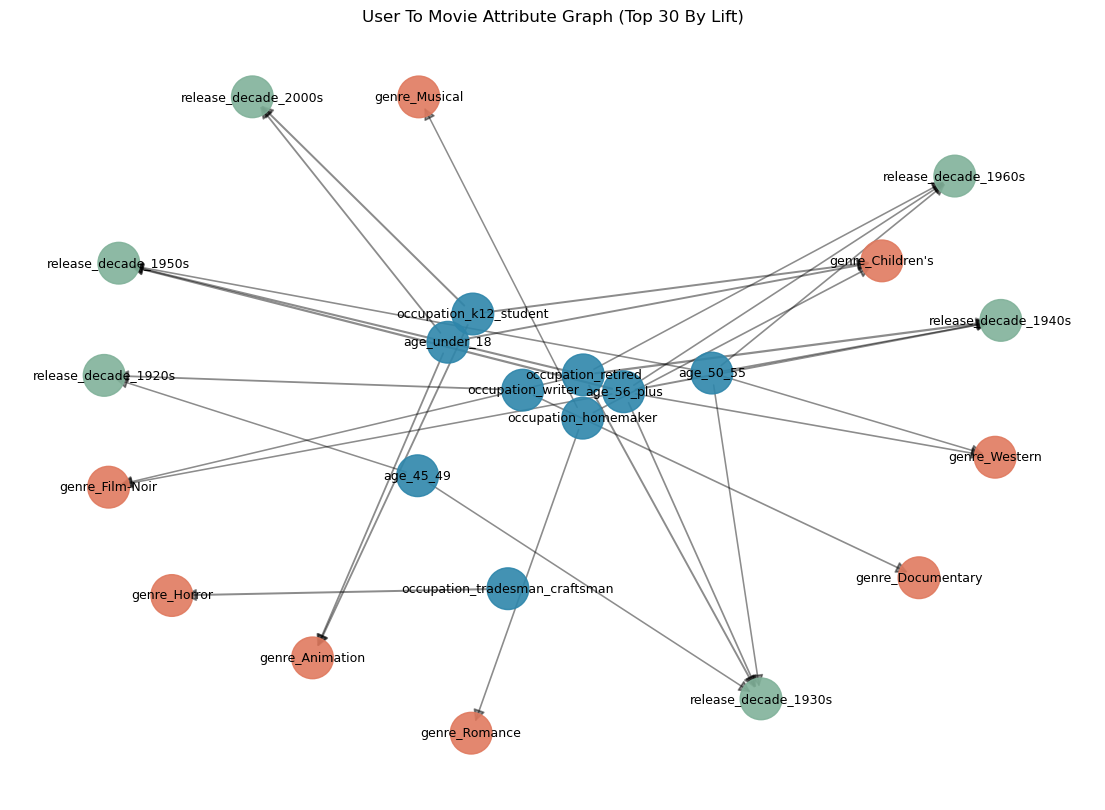

In [174]:
draw_graph(
    extract_top_weight_subgraph(user_movie_graph, top_n_edges=30),
    title="User To Movie Attribute Graph (Top 30 By Lift)",
    figsize=(14, 10),
    edge_width_scale=1.0,
)

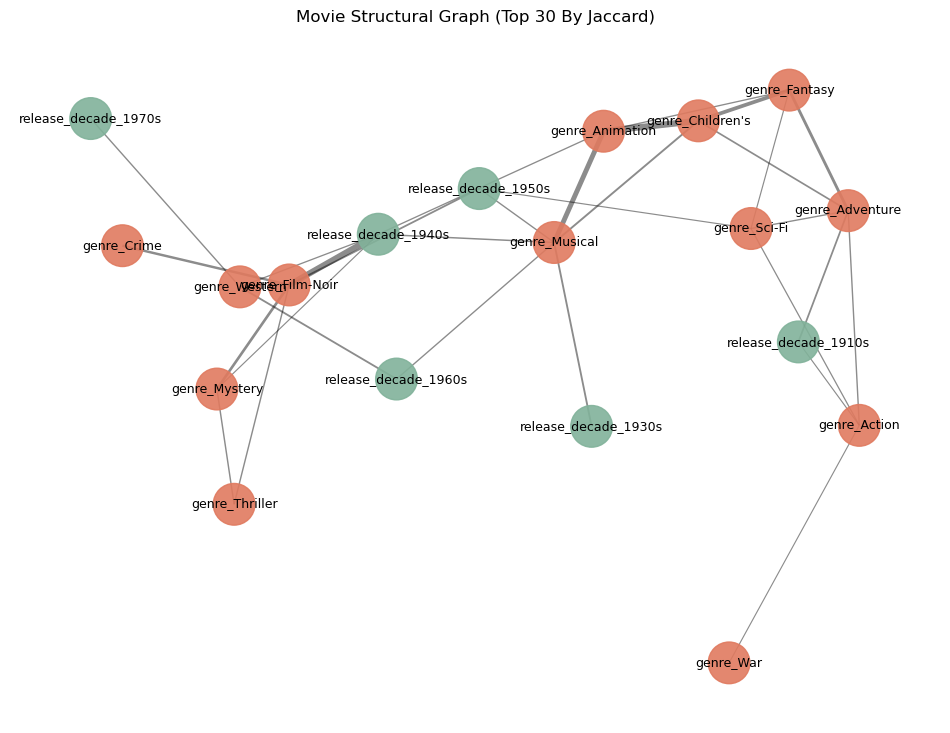

In [175]:
draw_graph(
    extract_top_weight_subgraph(movie_structural_graph, top_n_edges=30),
    title="Movie Structural Graph (Top 30 By Jaccard)",
    figsize=(12, 9),
)

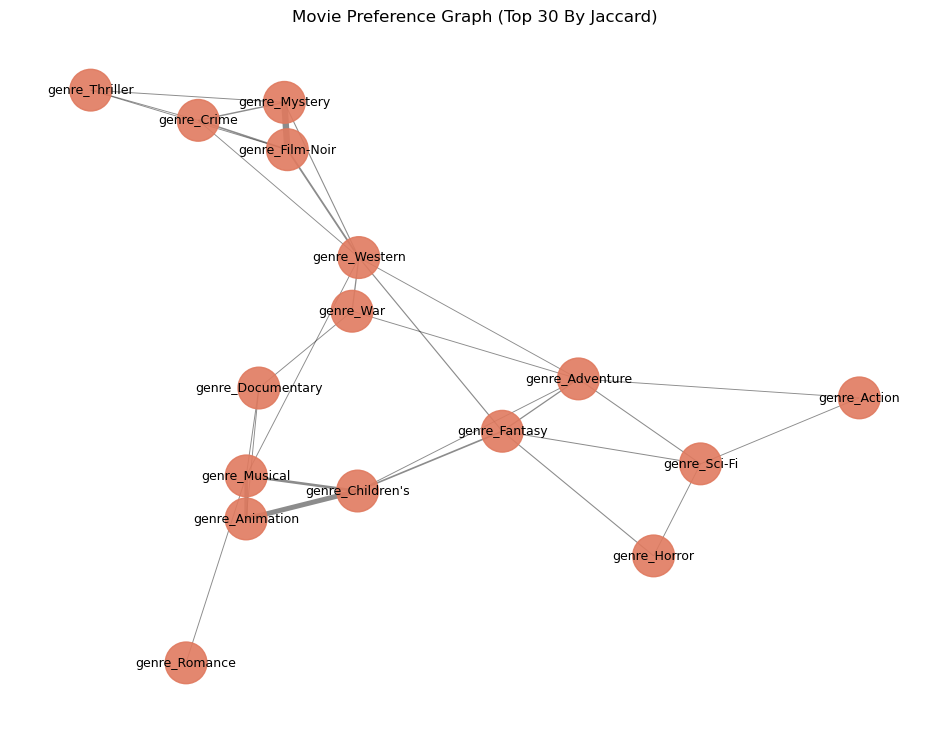

In [176]:
draw_graph(
    extract_top_weight_subgraph(movie_preference_graph, top_n_edges=30),
    title="Movie Preference Graph (Top 30 By Jaccard)",
    figsize=(12, 9),
)

## Interactive Graph Visualization

`plotly` を使って、`all_graph_edges` を `edge_type` ごとに min-max 正規化した `display_weight` で統合可視化する。


In [177]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [181]:
import plotly.graph_objects as go

MIN_DISPLAY_WEIGHT = 0.45
interactive_combined_subgraph = extract_weight_threshold_subgraph(
    combined_attribute_graph,
    min_weight=MIN_DISPLAY_WEIGHT,
    weight_attr="display_weight",
)

node_color_map = {
    "user_attribute": "#2E86AB",
    "movie_genre": "#E07A5F",
    "movie_decade": "#81B29A",
}
edge_color_map = {
    True: "rgba(58, 99, 140, 0.60)",
    False: "rgba(120, 120, 120, 0.45)",
}

pos = nx.spring_layout(
    interactive_combined_subgraph,
    seed=42,
    k=0.9,
    weight="display_weight",
)

max_display_weight = max(
    (attrs["display_weight"] for _, _, attrs in interactive_combined_subgraph.edges(data=True)),
    default=1.0,
)

edge_traces = []
edge_hover_x = []
edge_hover_y = []
edge_hover_text = []
arrow_annotations = []
seen_undirected_pairs = set()

for source, target, attrs in interactive_combined_subgraph.edges(data=True):
    if not attrs["is_directed"]:
        pair_key = tuple(sorted((source, target)))
        if pair_key in seen_undirected_pairs:
            continue
        seen_undirected_pairs.add(pair_key)

    x0, y0 = pos[source]
    x1, y1 = pos[target]
    width = 1.0 + 6.0 * ((attrs["display_weight"] / max_display_weight) ** 1.8)
    hover_text = (
        f"{source} -> {target}<br>"
        f"edge_type={attrs['edge_type']}<br>"
        f"display_weight={attrs['display_weight']:.3f}<br>"
        f"raw_weight={attrs['weight']:.3f}<br>"
        f"raw_count={attrs['raw_count']}<br>"
        f"metric={attrs['weight_metric']}<br>"
        f"is_directed={attrs['is_directed']}"
    )
    edge_traces.append(
        go.Scatter(
            x=[x0, x1, None],
            y=[y0, y1, None],
            mode="lines",
            line={
                "width": width,
                "color": edge_color_map[attrs["is_directed"]],
                "dash": "solid" if attrs["is_directed"] else "dot",
            },
            hoverinfo="skip",
            showlegend=False,
        )
    )
    edge_hover_x.append((x0 + x1) / 2)
    edge_hover_y.append((y0 + y1) / 2)
    edge_hover_text.append(hover_text)

    if attrs["is_directed"]:
        dx = x1 - x0
        dy = y1 - y0
        arrow_annotations.append(
            {
                "x": x1,
                "y": y1,
                "ax": x1 - dx * 0.18,
                "ay": y1 - dy * 0.18,
                "xref": "x",
                "yref": "y",
                "axref": "x",
                "ayref": "y",
                "showarrow": True,
                "arrowhead": 2,
                "arrowsize": 1.2,
                "arrowwidth": max(1.0, width * 0.45),
                "arrowcolor": edge_color_map[True],
            }
        )

edge_hover_trace = go.Scatter(
    x=edge_hover_x,
    y=edge_hover_y,
    mode="markers",
    hoverinfo="text",
    hovertext=edge_hover_text,
    marker={"size": 22, "color": "rgba(0, 0, 0, 0)"},
    showlegend=False,
)

node_x = []
node_y = []
node_text = []
node_hover_text = []
node_color = []

for node, attrs in interactive_combined_subgraph.nodes(data=True):
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)
    node_color.append(node_color_map.get(attrs.get("node_type"), "#999999"))
    node_hover_text.append(
        f"node={node}<br>node_type={attrs.get('node_type')}<br>node_group={attrs.get('node_group')}"
    )

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers+text",
    text=node_text,
    textposition="top center",
    hoverinfo="text",
    hovertext=node_hover_text,
    marker={
        "size": 30,
        "color": node_color,
        "line": {"width": 1.5, "color": "white"},
    },
    showlegend=False,
)

legend_traces = [
    go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker={"size": 12, "color": color},
        name=label,
        hoverinfo="skip",
    )
    for label, color in [
        ("User Attribute", "#2E86AB"),
        ("Movie Genre", "#E07A5F"),
        ("Movie Decade", "#81B29A"),
    ]
] + [
    go.Scatter(
        x=[None, None],
        y=[None, None],
        mode="lines",
        line={"width": 3, "color": edge_color_map[True]},
        name="Directed Edge",
        hoverinfo="skip",
    ),
    go.Scatter(
        x=[None, None],
        y=[None, None],
        mode="lines",
        line={"width": 3, "color": edge_color_map[False], "dash": "dot"},
        name="Undirected Edge",
        hoverinfo="skip",
    ),
]

fig = go.Figure(data=edge_traces + [edge_hover_trace, node_trace] + legend_traces)
fig.update_layout(
    title=f"Combined Attribute Graph (display_weight >= {MIN_DISPLAY_WEIGHT})",
    width=1300,
    height=900,
    paper_bgcolor="white",
    plot_bgcolor="white",
    hovermode="closest",
    margin={"l": 20, "r": 20, "t": 60, "b": 20},
    xaxis={"showgrid": False, "zeroline": False, "visible": False},
    yaxis={"showgrid": False, "zeroline": False, "visible": False},
    legend={"orientation": "h", "yanchor": "bottom", "y": 1.02, "xanchor": "right", "x": 1},
    annotations=arrow_annotations,
)
fig.show()
